In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

In [3]:
train_data = np.load("data_processed/train_data_scaled.npz")
test_data = np.load("data_processed/test_data_scaled.npz")
X_train = train_data["x"]
X_test = test_data["x"]

In [4]:
X = X_train 
mu = np.mean(X, axis=0)

# Relevant quantity if Proposition 3 contains |X_j - E[X_j]|
mean_abs_centered = np.mean(np.abs(X - mu), axis=0)

# Relevant quantity if X is already centered/standardized
mean_abs = np.mean(np.abs(X), axis=0)

print(f"Median E|X_j| : {np.median(mean_abs):.3f}")
print(f"Mean   E|X_j| : {np.mean(mean_abs):.3f}")
print(f"Max    E|X_j| : {np.max(mean_abs):.3f}")

Median E|X_j| : 0.759
Mean   E|X_j| : 0.694
Max    E|X_j| : 0.851


In [5]:
mu = np.mean(X, axis=0)

m = np.mean(np.abs(X - mu), axis=0)

m_sorted = np.sort(m)[::-1]

print("median =", np.median(m))
print("mean   =", np.mean(m))
print("max    =", np.max(m))

median = 0.7594036
mean   = 0.69395286
max    = 0.8514002


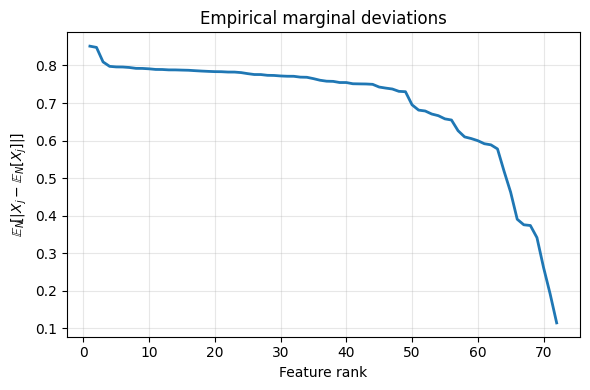

In [6]:
plt.figure(figsize=(6,4))

plt.plot(
    np.arange(1, len(m_sorted)+1),
    m_sorted,
    linewidth=2
)

plt.xlabel("Feature rank")
plt.ylabel(r"$\mathbb{E}_N\!\left[|X_j-\mathbb{E}_N[X_j]|\right]$")
plt.title("Empirical marginal deviations")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

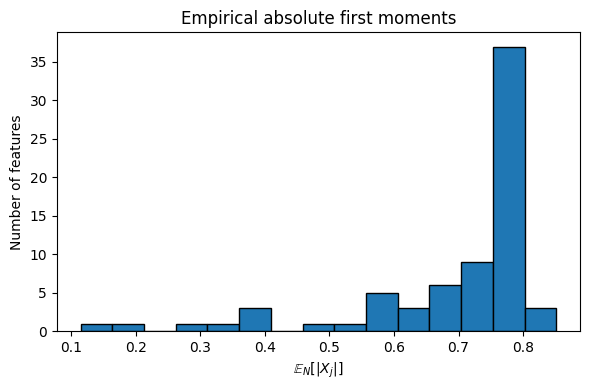

In [8]:
plt.figure(figsize=(6,4))

plt.hist(mean_abs, bins=15, edgecolor="black")

plt.xlabel(r"$\mathbb{E}_N[|X_j|]$")
plt.ylabel("Number of features")
plt.title("Empirical absolute first moments")

plt.tight_layout()
plt.show()